# Práctica 2: Sección 3.6
## Descriptores clásicos: Local Binary Patterns (LBP) y Histogram of Oriented Gradients (HOG)

**Entrada:** `muestra_procesada`, lista de tuplas `(ruta, clase, bgr, mascara)`.

**Salida:**
- Mapas de características visuales (LBP y HOG) en `figs/`.
- Matriz de datos procesada (LBP + HOG combinados) en `features/`

---
### Contenido
1. Configuración y reconstrucción del pipeline base
2. Preparación de la imagen para los descriptores
3. LBP:textura local
4. HOG:gradientes y estructura
5. Vector combinado (LBP + HOG)
6. Armado de la matriz de datos para clasificación
7. Conclusiones

## 1. Configuración y pipeline base

> Las funciones de esta sección son una **copia fiel** de la celda 3 de
> `practica_2_playground.ipynb`. Si el pipeline cambia, actualizar `CONFIG_PIPELINE`.
>
> (Mejora pendiente para el grupo: mover estas funciones a un `pipeline.py`
> que ambos notebooks importen, para no duplicar código.)

In [48]:
import os, random
import numpy as np
import cv2
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

# ---- Dataset ----
LOCAL_DATASET = False   # True si ya lo tienes descargado localmente

if LOCAL_DATASET:
    path = "../../../../../Downloads/archive"   # ajustar a tu ruta
else:
    import kagglehub
    path = kagglehub.dataset_download("emmarex/plantdisease")

DATA_DIR = os.path.join(path, "PlantVillage")
print("DATA_DIR:", DATA_DIR)

# ---- Carpetas de salida ----
FIGS = "figs"
FEATS = "features"
os.makedirs(FIGS, exist_ok=True)
os.makedirs(FEATS, exist_ok=True)

def guardar(nombre):
    """Guarda la figura actual en figs/ con buena resolución."""
    ruta = os.path.join(FIGS, nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print("guardado:", ruta)

DATA_DIR: C:\Users\sauto\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage


In [36]:
# ============================================================
# COPIA del pipeline base (practica_2_playground.ipynb, celda 3)
# ============================================================

def to_grayscale(bgr):
    """Escala de grises por luminosidad (ITU-R BT.601)."""
    b, g, r = bgr[:, :, 0], bgr[:, :, 1], bgr[:, :, 2]
    return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

def aplicar_filtro(gray, filtro, ksize):
    if filtro == 'gaussian':
        return cv2.GaussianBlur(gray, (ksize, ksize), 0)
    elif filtro == 'median':
        return cv2.medianBlur(gray, ksize)
    raise ValueError("filtro debe ser 'gaussian' o 'median'")

def cdf_histograma(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    cdf = np.cumsum(hist)
    return (cdf - cdf.min()) / (cdf.max() - cdf.min()) * 255

def ecualizar_histograma(gray):
    lut = cdf_histograma(gray).astype(np.uint8)
    return cv2.LUT(gray, lut)

def orient_leaf_as_foreground(mask):
    """Deja la hoja en blanco (asume que el fondo domina el borde de la imagen)."""
    border = np.concatenate([mask[0, :], mask[-1, :], mask[:, 0], mask[:, -1]])
    return cv2.bitwise_not(mask) if border.mean() > 100 else mask

def segmentar(gray, metodo, global_t=127):
    if metodo == 'global':
        _, m = cv2.threshold(gray, global_t, 255, cv2.THRESH_BINARY)
        return orient_leaf_as_foreground(m)
    elif metodo == 'otsu':
        _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return orient_leaf_as_foreground(m)
    raise ValueError("método desconocido: " + str(metodo))

def aplicar_morfologia(mask, operacion, ksize):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    if operacion == 'erosion':
        return cv2.erode(mask, kernel, iterations=1)
    elif operacion == 'dilatacion':
        return cv2.dilate(mask, kernel, iterations=1)
    elif operacion == 'apertura':
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    elif operacion == 'cierre':
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    raise ValueError("operación desconocida: " + str(operacion))

def construir_pipeline(filtro='gaussian', ksize_filtro=5, contraste=False,
                       metodo_seg='otsu', global_t=127, operaciones_morf=()):
    pasos = [('Gris', to_grayscale)]
    if contraste:
        pasos.append(('Contraste (CDF)', ecualizar_histograma))
    pasos.append(('Filtro', lambda img: aplicar_filtro(img, filtro, ksize_filtro)))
    pasos.append(('Segmentacion', lambda img: segmentar(img, metodo_seg, global_t)))
    for op, ksize in operaciones_morf:
        pasos.append((op.capitalize() + " (k=" + str(ksize) + ")",
                      lambda img, op=op, ksize=ksize: aplicar_morfologia(img, op, ksize)))
    return pasos

def ejecutar_pipeline(bgr, pasos):
    actual = bgr
    for nombre, fn in pasos:
        actual = fn(actual)
    return actual

print("Funciones del pipeline listas.")

Funciones del pipeline listas.


In [49]:
# --- Configuración del pipeline final (P2, acordado por el grupo) ---
CONFIG_PIPELINE = dict(
    filtro='gaussian',
    ksize_filtro=5,
    contraste=True,
    metodo_seg='otsu',
    operaciones_morf=[('dilatacion', 11), ('erosion', 3)],
)

PIPELINE_FINAL = construir_pipeline(**CONFIG_PIPELINE)

def procesar_hasta_operaciones_morfologicas(ruta):
    """Corre el pipeline final sobre una imagen.
    Devuelve (bgr_original, mascara_binaria)."""
    bgr = cv2.imread(ruta)
    mascara = ejecutar_pipeline(bgr, PIPELINE_FINAL)
    return bgr, mascara

print("Pipeline:", " -> ".join(n for n, _ in PIPELINE_FINAL))

Pipeline: Gris -> Contraste (CDF) -> Filtro -> Segmentacion -> Dilatacion (k=11) -> Erosion (k=3)


### Selección de clases e imágenes de muestra

No necesitamos las 15 clases. Para las figuras del informe bastan **una hoja sana y
tres enfermas** con patrones visualmente distintos:

| Clase | Por qué |
|---|---|
| `Tomato_healthy` | Control: sin lesiones, superficie uniforme |
| `Tomato_Early_blight` | Lesiones grandes con anillos concéntricos |
| `Tomato_Septoria_leaf_spot` | Muchas manchas pequeñas y bien delimitadas |
| `Tomato__Tomato_YellowLeaf__Curl_Virus` | Deformación del contorno, sin manchas focales |

Para las **figuras** (mapas LBP/HOG) alcanza con una imagen por clase. Para la **matriz de
datos** de cara a la clasificación (3.7) se usan `N_POR_CLASE_DATOS` imágenes por clase.

In [51]:
def get_class_dirs(data_dir=DATA_DIR):
    return sorted(d for d in os.listdir(data_dir)
                  if os.path.isdir(os.path.join(data_dir, d))
                  and d.lower() != "plantvillage")

DISPONIBLES = get_class_dirs()

PATRONES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Septoria",
    "YellowLeaf",
]

def resolver_clases(patrones, disponibles=DISPONIBLES):
    elegidas = []
    for p in patrones:
        match = [c for c in disponibles if p.lower() in c.lower()]
        if match:
            elegidas.append(match[0])
        else:
            print("[!] no se encontró la clase:", p)
    return elegidas

CLASES_FOCO = resolver_clases(PATRONES)
print("Clases seleccionadas:")
for c in CLASES_FOCO:
    print("  -", c)

def es_sana(clase):
    return "healthy" in clase.lower()

def etiqueta_corta(clase):
    """Nombre legible para los títulos de las figuras."""
    return (clase.replace("Tomato_", "").replace("Tomato__", "")
                 .replace("_", " ").replace("  ", " ").strip())

def imagenes_de_clase(clase, data_dir=DATA_DIR, n=1, seed=42):
    random.seed(seed)
    cdir = os.path.join(data_dir, clase)
    exts = ('.png', '.jpg', '.jpeg', '.bmp')
    imgs = sorted(f for f in os.listdir(cdir) if f.lower().endswith(exts))
    return [os.path.join(cdir, f) for f in random.sample(imgs, min(n, len(imgs)))]

Clases seleccionadas:
  - Tomato_healthy
  - Tomato_Early_blight
  - Tomato_Septoria_leaf_spot
  - Tomato__Tomato_YellowLeaf__Curl_Virus


In [52]:
# una imagen por clase
muestra_procesada = []
for clase in CLASES_FOCO:
    for ruta in imagenes_de_clase(clase, n=1):
        bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
        muestra_procesada.append((ruta, clase, bgr, mascara))

print("Imágenes de muestra:", len(muestra_procesada))
for ruta, clase, bgr, mascara in muestra_procesada:
    print("  ", etiqueta_corta(clase), "->", bgr.shape)

Imágenes de muestra: 4
   healthy -> (256, 256, 3)
   Early blight -> (256, 256, 3)
   Septoria leaf spot -> (256, 256, 3)
   YellowLeaf Curl Virus -> (256, 256, 3)


## 2. Preparación de la imagen para los descriptores

LBP y HOG se calculan sobre una sola banda de intensidad, no sobre color. Similar a 3.4/3.5, los descriptores se calculan **con el fondo descartado** (máscara aplicada sobre el gris) para que la textura/gradiente del fondo no contamine el vector de características de la hoja.

Además, HOG produce un vector cuya longitud depende del tamaño de la imagen de entrada. Como la matriz de datos final necesita una columna por característica igual para todas las filas, todas las imágenes se llevan a un tamaño fijo `TAM_DESCRIPTOR` antes de extraer los descriptores.

In [53]:
TAM_DESCRIPTOR = (128, 128)  # tamaño fijo,vectores HOG de igual longitud para todas las imágenes

def preparar_para_descriptores(bgr, mascara, tam=TAM_DESCRIPTOR):
    """Gris + fondo descartado (mismo criterio que 3.4/3.5) + tamaño fijo."""
    gray = to_grayscale(bgr)
    gray = cv2.bitwise_and(gray, gray, mask=mascara)
    return cv2.resize(gray, tam, interpolation=cv2.INTER_AREA)

# Prueba
ruta, clase, bgr, mascara = muestra_procesada[0]
gray_prep = preparar_para_descriptores(bgr, mascara)
print(etiqueta_corta(clase), "->", gray_prep.shape, gray_prep.dtype)

healthy -> (128, 128) uint8


## 3. Sección 3.6: LBP 

**Local Binary Patterns.** Para cada píxel se compara su intensidad con la de sus `P` vecinos sobre un círculo de radio `R`: cada vecino aporta un bit (1 si es mayor o igual al centro, 0 sino) y esos bits forman un código de textura local. Se usa la variante **uniforme** (`method='uniform'`), que agrupa todos los patrones con más de 2 transiciones 0-1 en un único bin "no uniforme": son los más frecuentes en texturas reales y reduce el histograma de `2^P` a `P + 2` bins.

Con `P=8, R=1` (8 vecinos a distancia 1 px) el histograma queda en 10 bins. El **mapa LBP** es la imagen completa con el código de cada píxel; el **vector de características** es el histograma normalizado de esos códigos.

In [54]:
from skimage.feature import local_binary_pattern

LBP_RADIO = 1
LBP_PUNTOS = 8 * LBP_RADIO
LBP_METODO = 'uniform'
LBP_N_BINS = LBP_PUNTOS + 2   # patrones uniformes (0..P) + 1 bin para el resto

def lbp_mapa(gray):
    """Imagen donde cada píxel es su código LBP (textura local)."""
    return local_binary_pattern(gray, LBP_PUNTOS, LBP_RADIO, method=LBP_METODO)

def lbp_histograma(lbp_img):
    """Histograma normalizado del mapa LBP: el vector de características de textura."""
    hist, _ = np.histogram(lbp_img.ravel(), bins=LBP_N_BINS, range=(0, LBP_N_BINS))
    hist = hist.astype(np.float64)
    return hist / (hist.sum() + 1e-7)

# Prueba
h = lbp_histograma(lbp_mapa(gray_prep))
print("Histograma LBP:", h.shape, "| suma =", round(h.sum(), 3))

Histograma LBP: (10,) | suma = 1.0


guardado: figs\05_lbp_mapas.png


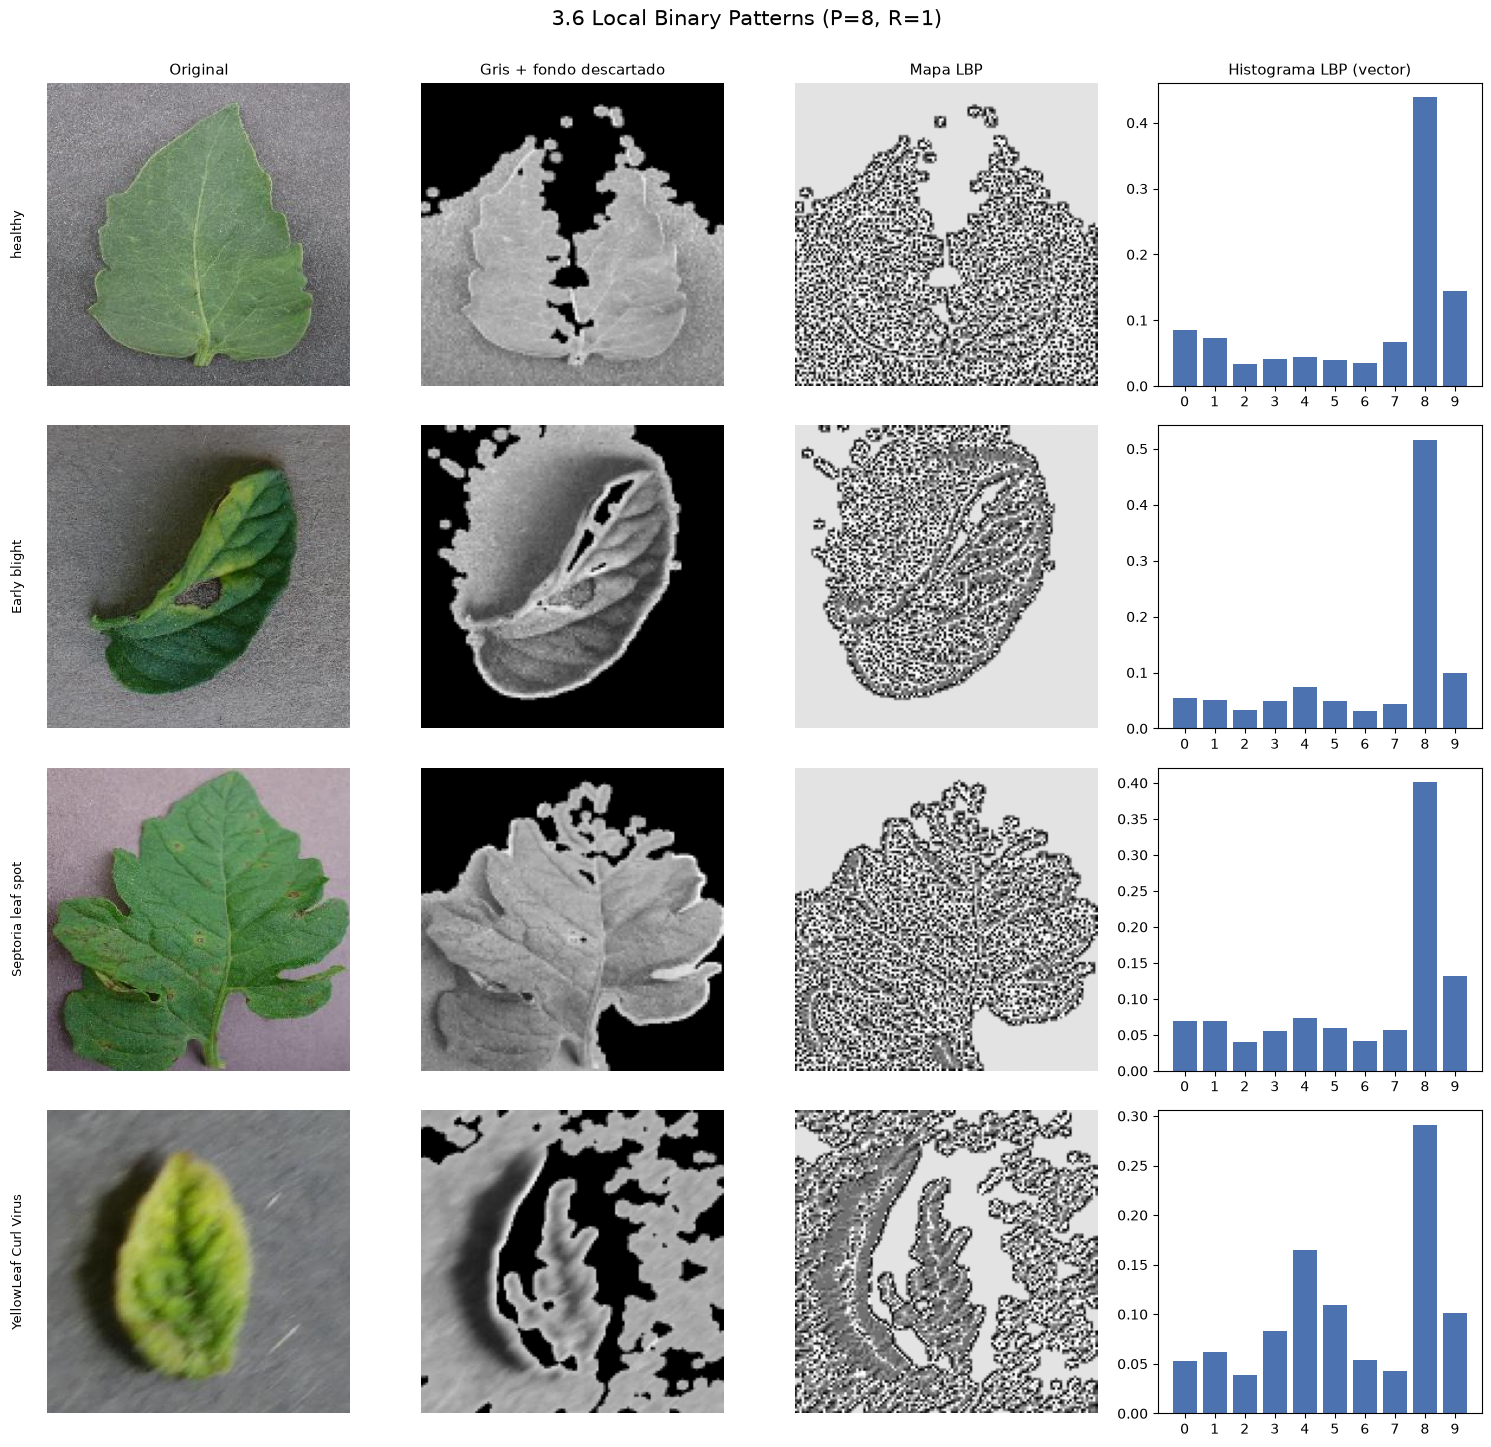

In [55]:
# --- Figura: mapas de LBP por clase ---
fig, axes = plt.subplots(len(muestra_procesada), 4,
                         figsize=(15, 3.6 * len(muestra_procesada)))
if len(muestra_procesada) == 1:
    axes = axes[np.newaxis, :]

for i, (ruta, clase, bgr, mascara) in enumerate(muestra_procesada):
    gray = preparar_para_descriptores(bgr, mascara)
    mapa = lbp_mapa(gray)
    hist = lbp_histograma(mapa)

    axes[i, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original" if i == 0 else "", fontsize=11)
    axes[i, 0].axis('off')
    axes[i, 0].text(-0.1, 0.5, etiqueta_corta(clase), transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title("Gris + fondo descartado" if i == 0 else "", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mapa, cmap='gray')
    axes[i, 2].set_title("Mapa LBP" if i == 0 else "", fontsize=11)
    axes[i, 2].axis('off')

    axes[i, 3].bar(range(LBP_N_BINS), hist, color="#4C72B0")
    axes[i, 3].set_title("Histograma LBP (vector)" if i == 0 else "", fontsize=11)
    axes[i, 3].set_xticks(range(LBP_N_BINS))

plt.suptitle("3.6 Local Binary Patterns (P=" + str(LBP_PUNTOS) + ", R=" + str(LBP_RADIO) + ")",
             fontsize=15, y=1.002)
plt.tight_layout()
guardar("05_lbp_mapas.png")
plt.show()

## 4. Sección 3.6: HOG

**Histogram of Oriented Gradients.** Divide la imagen en celdas, calcula el gradiente en cada píxel y arma un histograma de orientaciones por celda. Los histogramas se normalizan en bloques de celdas superpuestos para ser menos sensibles a cambios de iluminación. El resultado captura la forma y estructura de bordes/lesiones, a diferencia de LBP, que describe textura fina.

Parámetros clásicos (Dalal & Triggs): 9 orientaciones, celdas de 16x16 píxeles, bloques de 2x2
celdas.

In [56]:
from skimage.feature import hog

HOG_PARAMS = dict(orientations=9, pixels_per_cell=(16, 16),
                  cells_per_block=(2, 2), block_norm='L2-Hys')

def hog_vector_y_mapa(gray):
    """Vector HOG (características) + imagen de visualización de los gradientes."""
    vector, mapa = hog(gray, visualize=True, **HOG_PARAMS)
    return vector, mapa

# Prueba
v, m = hog_vector_y_mapa(gray_prep)
print("Vector HOG:", v.shape, "| mapa de visualización:", m.shape)

Vector HOG: (1764,) | mapa de visualización: (128, 128)


guardado: figs\06_hog_mapas.png


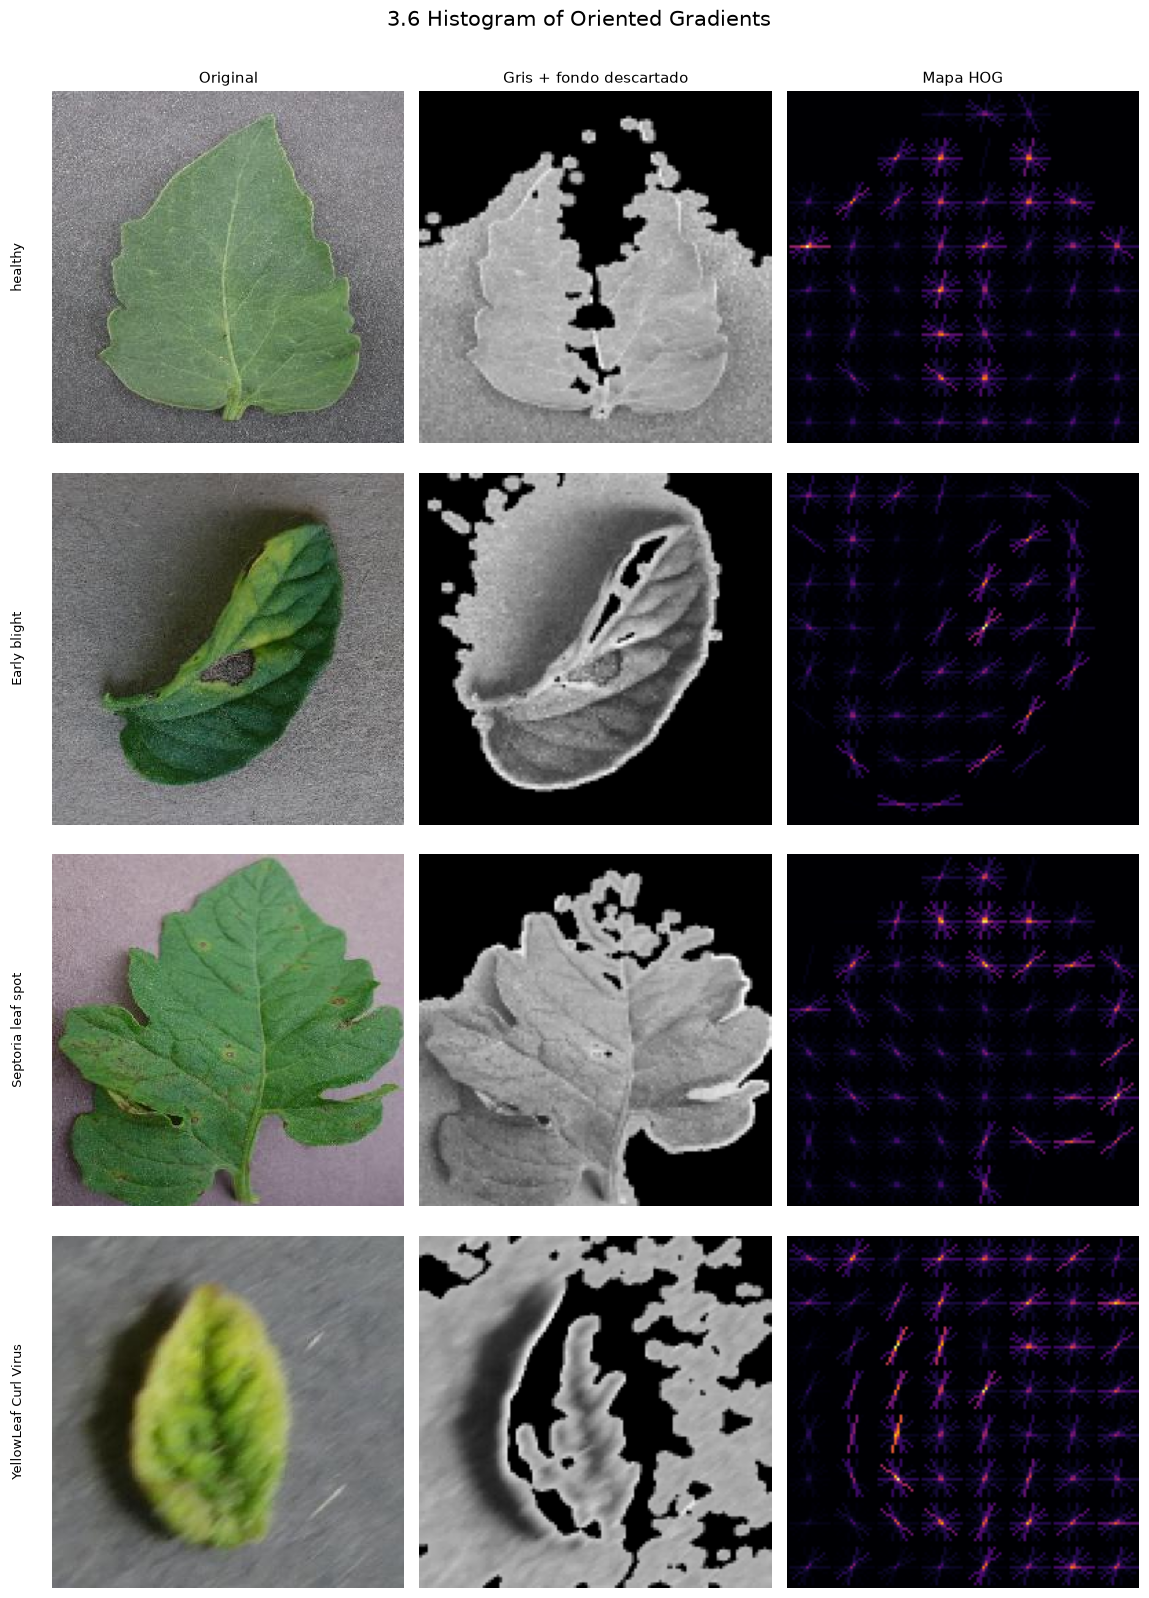

In [57]:
# --- Figura: mapas de HOG por clase ---
fig, axes = plt.subplots(len(muestra_procesada), 3,
                         figsize=(11.5, 4.0 * len(muestra_procesada)))
if len(muestra_procesada) == 1:
    axes = axes[np.newaxis, :]

for i, (ruta, clase, bgr, mascara) in enumerate(muestra_procesada):
    gray = preparar_para_descriptores(bgr, mascara)
    _, mapa = hog_vector_y_mapa(gray)

    axes[i, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original" if i == 0 else "", fontsize=11)
    axes[i, 0].axis('off')
    axes[i, 0].text(-0.1, 0.5, etiqueta_corta(clase), transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title("Gris + fondo descartado" if i == 0 else "", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mapa, cmap='inferno')
    axes[i, 2].set_title("Mapa HOG" if i == 0 else "", fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle("3.6 Histogram of Oriented Gradients", fontsize=15, y=1.002)
plt.tight_layout()
guardar("06_hog_mapas.png")
plt.show()

## 5. Vector combinado (LBP + HOG)

Cada imagen queda representada por la concatenación del histograma LBP (textura) y el vector
HOG (estructura/gradiente): dos descriptores complementarios en un solo vector.

In [58]:
def extraer_descriptores(bgr, mascara):
    """Vector de características combinado: histograma LBP + vector HOG."""
    gray = preparar_para_descriptores(bgr, mascara)
    lbp = lbp_histograma(lbp_mapa(gray))
    hog_vec, _ = hog_vector_y_mapa(gray)
    return np.concatenate([lbp, hog_vec])

# Prueba
ruta, clase, bgr, mascara = muestra_procesada[0]
vec = extraer_descriptores(bgr, mascara)
print("Vector combinado:", vec.shape, "=", LBP_N_BINS, "(LBP) +", vec.shape[0] - LBP_N_BINS, "(HOG)")

Vector combinado: (1774,) = 10 (LBP) + 1764 (HOG)


## 6. Matriz de datos para clasificación

Se arma la matriz `X` (una fila por imagen, una columna por característica) y el vector de
etiquetas `y`, usando `N_POR_CLASE_DATOS` imágenes de cada una de las 4 clases foco. Esta
matriz es la entrada de los clasificadores de la sección 3.7 (kNN, SVM, Random Forest).

In [59]:
N_POR_CLASE_DATOS = 40

filas, vectores = [], []
for clase in CLASES_FOCO:
    for ruta in imagenes_de_clase(clase, n=N_POR_CLASE_DATOS):
        bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
        vectores.append(extraer_descriptores(bgr, mascara))
        filas.append({"ruta": ruta, "clase": clase, "sana": es_sana(clase)})

X = np.vstack(vectores)
y = np.array([f["clase"] for f in filas])

print("Matriz de características X:", X.shape)
print("  -> filas: imágenes  (", N_POR_CLASE_DATOS, "por clase x", len(CLASES_FOCO), "clases )")
print("  -> columnas: 0.." + str(LBP_N_BINS - 1), "= LBP  |", LBP_N_BINS, "..", X.shape[1] - 1, "= HOG")
print("Etiquetas y:", y.shape, "-> clases:", sorted(set(y)))

Matriz de características X: (160, 1774)
  -> filas: imágenes  ( 40 por clase x 4 clases )
  -> columnas: 0..9 = LBP  | 10 .. 1773 = HOG
Etiquetas y: (160,) -> clases: [np.str_('Tomato_Early_blight'), np.str_('Tomato_Septoria_leaf_spot'), np.str_('Tomato__Tomato_YellowLeaf__Curl_Virus'), np.str_('Tomato_healthy')]


In [62]:
import pandas as pd

n_hog = X.shape[1] - LBP_N_BINS
columnas = [f"lbp_{i}" for i in range(LBP_N_BINS)] + [f"hog_{i}" for i in range(n_hog)]

df = pd.DataFrame(X, columns=columnas)
df.insert(0, "sana", [f["sana"] for f in filas])
df.insert(0, "clase", [f["clase"] for f in filas])
df.insert(0, "ruta", [f["ruta"] for f in filas])

ruta_csv = os.path.join(FEATS, "lbp_hog_features.csv")
df.to_csv(ruta_csv, index=False)
print("guardado:", ruta_csv, "|", df.shape)

ruta_npz = os.path.join(FEATS, "lbp_hog_features.npz")
np.savez(ruta_npz, X=X, y=y, n_lbp=LBP_N_BINS,
        rutas=np.array([f["ruta"] for f in filas]))
print("guardado:", ruta_npz)

df.head()

guardado: features\lbp_hog_features.csv | (160, 1777)
guardado: features\lbp_hog_features.npz


,ruta,clase,sana,lbp_0,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
0,C:\Users\sauto\.cache\kagglehub\datasets\emmar...,Tomato_healthy,True,0.085571,0.072754,0.032898,0.041565,0.044373,0.039307,0.034729,...,0.129367,0.216275,0.135359,0.171180,0.131219,0.161983,0.154819,0.153990,0.153696,0.114762
1,C:\Users\sauto\.cache\kagglehub\datasets\emmar...,Tomato_healthy,True,0.077820,0.066223,0.028687,0.034363,0.044922,0.037292,0.031555,...,0.160810,0.171674,0.117160,0.085536,0.159033,0.145058,0.128563,0.118054,0.100605,0.126446
2,C:\Users\sauto\.cache\kagglehub\datasets\emmar...,Tomato_healthy,True,0.075623,0.060059,0.028259,0.033936,0.040283,0.035156,0.029846,...,0.133475,0.149803,0.149748,0.127721,0.087975,0.156213,0.154422,0.100134,0.123676,0.097553
3,C:\Users\sauto\.cache\kagglehub\datasets\emmar...,Tomato_healthy,True,0.094482,0.076721,0.032776,0.043213,0.051208,0.049194,0.039612,...,0.145583,0.219006,0.159181,0.184970,0.170316,0.147864,0.148058,0.103991,0.092687,0.131204
4,C:\Users\sauto\.cache\kagglehub\datasets\emmar...,Tomato_healthy,True,0.093140,0.081665,0.037109,0.051636,0.064514,0.054993,0.035278,...,0.136345,0.140777,0.089597,0.098881,0.116727,0.183935,0.104686,0.163486,0.208242,0.153061


## Bag of Words, Fisher Vector y descriptor propio

In [ ]:
from scipy import ndimage
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from skimage.feature import graycomatrix, graycoprops

### Ajuste de máscara, canal de análisis y muestra ampliada

Para los descriptores de esta sección conviene una máscara más ceñida al contorno real de la hoja (`ajustar_mascara`) y trabajar sobre un canal específico (`canal_analisis`, por defecto el canal *a\** de Lab). También se amplía la muestra a `n_por_clase` imágenes por clase (antes 1) para tener suficientes descriptores locales con los que entrenar el vocabulario BoW y el GMM de Fisher Vector.

In [64]:
K_COMPENSA = 9      
CANAL = 'lab_a'     # canal por defecto
 
def mantener_componente_mayor(mascara):
    """Descarta cualquier blob de la mascara que este desconectado del
    cuerpo principal de la hoja (ruido de fondo que sobrevivio a Otsu +
    la dilatacion del pipeline compartido)."""
    etiquetas, n = ndimage.label(mascara > 0)
    if n <= 1:
        return mascara
    tamanos = ndimage.sum(mascara > 0, etiquetas, index=range(1, n + 1))
    mayor = np.argmax(tamanos) + 1
    return np.where(etiquetas == mayor, 255, 0).astype(np.uint8)


def ajustar_mascara(mascara, k=K_COMPENSA):
    """Erosion compensatoria: mascara cenida al contorno real de la hoja,
    despues de descartar blobs de fondo desconectados."""
    mascara = mantener_componente_mayor(mascara)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.erode(mascara, kernel, iterations=1)
 
def canal_analisis(bgr, modo=None):
    """Canal de una banda sobre el que se calculan los descriptores."""
    modo = modo or CANAL
    if modo == 'gris':
        return to_grayscale(bgr)
    if modo == 'lab_a':
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)[:, :, 1]
    if modo == 'exceso_verde':
        b = bgr[:, :, 0].astype(np.int16)
        g = bgr[:, :, 1].astype(np.int16)
        r = bgr[:, :, 2].astype(np.int16)
        return np.clip(2 * g - r - b, 0, 255).astype(np.uint8)
    raise ValueError("canal desconocido: " + str(modo))

In [ ]:
def construir_muestra_procesada(n_por_clase=6, seed=42):
    muestra = []
    for clase in CLASES_FOCO:
        for ruta in imagenes_de_clase(clase, n=n_por_clase, seed=seed):
            bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
            muestra.append((ruta, clase, bgr, mascara))
    return muestra

In [66]:
muestra_procesada = construir_muestra_procesada(n_por_clase=6)
print("Imagenes en la muestra:", len(muestra_procesada))
for ruta, clase, bgr, mascara in muestra_procesada[:3]:
    print(" ", etiqueta_corta(clase), "->", bgr.shape)

Imagenes en la muestra: 24
  healthy -> (256, 256, 3)
  healthy -> (256, 256, 3)
  healthy -> (256, 256, 3)


### Local Descriptor - SIFT

In [67]:
def extraer_descriptores_locales(bgr, mascara, canal=None, max_features=500,
                                  contrast_threshold=0.02, edge_threshold=15):
    """SIFT 'disperso' (detectAndCompute): el propio algoritmo decide donde
    hay suficiente contraste para poner un punto. Funciona bien en 'gris'
    pero falla en canales casi planos como 'lab_a' (ver diagnostico:
    218 keypoints en gris vs. 41 en a* con el mismo umbral)."""
    ch = canal_analisis(bgr, canal or 'gris')
    sift = cv2.SIFT_create(nfeatures=max_features,
                            contrastThreshold=contrast_threshold,
                            edgeThreshold=edge_threshold)
    mask_u8 = mascara.astype(np.uint8) if mascara is not None else None
    kp, des = sift.detectAndCompute(ch, mask=mask_u8)
    return kp, des

def _grilla_keypoints(mascara, paso=8, tamano=8):
    """Genera una grilla regular de keypoints, solo en pixeles donde la
    mascara es > 0. Con esto SIEMPRE hay puntos, sin importar cuanto
    contraste local tenga la region (a diferencia de detectAndCompute)."""
    kps = []
    h, w = mascara.shape
    for y in range(tamano, h - tamano, paso):
        for x in range(tamano, w - tamano, paso):
            if mascara[y, x] > 0:
                kps.append(cv2.KeyPoint(float(x), float(y), tamano))
    return kps

def extraer_descriptores_locales_dense(bgr, mascara, canal=None, paso=8, tamano=8):
    """SIFT 'denso': calcula el descriptor SIFT en una grilla fija dentro
    de la mascara, en vez de dejar que SIFT elija donde hay contraste.
    Usar esta version si se quiere trabajar sobre 'lab_a' (o cualquier
    canal casi plano) sin perder puntos por falta de textura. Tambien
    evita el sesgo de que hojas enfermas (mas contraste) aporten mas
    puntos al vocabulario que hojas sanas: aqui todas aportan el mismo
    numero de puntos (uno por celda de la grilla dentro de la hoja)."""
    ch = canal_analisis(bgr, canal)
    kps = _grilla_keypoints(mascara, paso, tamano)
    if not kps:
        return [], None
    sift = cv2.SIFT_create()
    kps, des = sift.compute(ch, kps)
    return kps, des
 
 
def _recolectar_descriptores(muestra, canal=None, max_desc_por_imagen=200, seed=42,
                              modo='dense', paso=8):
    """Junta descriptores locales de todas las imagenes de muestra, con un
    tope por imagen para que ninguna clase domine el ajuste del
    vocabulario/GMM por tener mas puntos SIFT. modo='dense' (default) usa
    grilla fija -recomendado para 'lab_a'-; modo='sparse' usa deteccion
    automatica de SIFT -recomendado solo con canal='gris'-."""
    rng = np.random.RandomState(seed)
    todos = []
    for _, _, bgr, mascara in muestra:
        maj = ajustar_mascara(mascara)
        if modo == 'dense':
            _, des = extraer_descriptores_locales_dense(bgr, maj, canal, paso=paso)
        else:
            _, des = extraer_descriptores_locales(bgr, maj, canal)
        if des is None or len(des) == 0:
            continue
        if len(des) > max_desc_por_imagen:
            idx = rng.choice(len(des), max_desc_por_imagen, replace=False)
            des = des[idx]
        todos.append(des)
    if not todos:
        raise RuntimeError("No se extrajo ningun descriptor SIFT de la muestra.")
    return np.vstack(todos).astype(np.float32)

### Bag of Words (BoW)

In [68]:

def construir_vocabulario_bow(muestra, k=64, canal=None, max_desc_por_imagen=200, seed=42,
                               modo='dense', paso=8):
    """Ajusta el vocabulario (k-means) UNA sola vez sobre el conjunto de
    entrenamiento. El mismo objeto kmeans debe reutilizarse para codificar
    cualquier imagen despues (train o test), nunca reajustarse por imagen."""
    todos = _recolectar_descriptores(muestra, canal, max_desc_por_imagen, seed, modo, paso)
    print(f"[BoW] descriptores para el vocabulario: {todos.shape}")
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans.fit(todos)
    return kmeans
 
 
def codificar_bow(bgr, mascara, kmeans, canal=None, modo='dense', paso=8):
    """Histograma de palabras visuales normalizado (suma 1) para una imagen."""
    maj = ajustar_mascara(mascara)
    if modo == 'dense':
        kp, des = extraer_descriptores_locales_dense(bgr, maj, canal, paso=paso)
    else:
        kp, des = extraer_descriptores_locales(bgr, maj, canal)
    k = kmeans.n_clusters
    hist = np.zeros(k, dtype=np.float32)
    etiquetas = None
    if des is not None and len(des) > 0:
        etiquetas = kmeans.predict(des.astype(np.float32))
        for e in etiquetas:
            hist[e] += 1
        if hist.sum() > 0:
            hist /= hist.sum()
    return hist, kp, etiquetas

In [69]:
kmeans_bow = construir_vocabulario_bow(muestra_procesada, k=64, canal=CANAL)

ruta, clase, bgr, mascara = muestra_procesada[1]
hist_bow, kp_bow, et_bow = codificar_bow(bgr, mascara, kmeans_bow, canal=CANAL)
print(etiqueta_corta(clase), "-> histograma BoW:", hist_bow.shape,
      "| keypoints:", len(kp_bow) if kp_bow else 0)

[BoW] descriptores para el vocabulario: (4800, 128)
healthy -> histograma BoW: (64,) | keypoints: 440


### Fisher Vector

In [70]:

def construir_gmm_fisher(muestra, k=32, canal=None, max_desc_por_imagen=200, seed=42,
                          modo='dense', paso=8):
    """Ajusta la mezcla de gaussianas (covarianza diagonal) una sola vez
    sobre el conjunto de entrenamiento, igual que el vocabulario de BoW."""
    todos = _recolectar_descriptores(muestra, canal, max_desc_por_imagen, seed, modo, paso)
    print(f"[Fisher] descriptores para el GMM: {todos.shape}")
    gmm = GaussianMixture(n_components=k, covariance_type='diag',
                           random_state=seed, reg_covar=1e-4)
    gmm.fit(todos)
    return gmm
 
 
def fisher_vector(des, gmm):
    """Codificacion Fisher Vector (Perronnin & Dance, 2007) con gradientes
    respecto a las medias y varianzas de cada componente (covarianza
    diagonal), seguida de power-normalization (signed sqrt) y
    L2-normalization, tal como se usa en la practica estandar."""
    k = gmm.n_components
    d = gmm.means_.shape[1]
 
    if des is None or len(des) == 0:
        return np.zeros(2 * k * d, dtype=np.float32)
 
    des = des.astype(np.float64)
    means = gmm.means_                 # (k, d)
    covs = gmm.covariances_            # (k, d), diagonal
    weights = gmm.weights_             # (k,)
 
    posteriors = gmm.predict_proba(des)   # (n, k), responsabilidades
    n = des.shape[0]
 
    grad_mu = np.zeros((k, d))
    grad_sigma = np.zeros((k, d))
    for i in range(k):
        gamma = posteriors[:, i][:, None]                  # (n, 1)
        diff = (des - means[i]) / np.sqrt(covs[i])          # (n, d)
        grad_mu[i] = (gamma * diff).sum(axis=0) / (n * np.sqrt(weights[i]) + 1e-9)
        grad_sigma[i] = (gamma * (diff ** 2 - 1)).sum(axis=0) / (n * np.sqrt(2 * weights[i]) + 1e-9)
 
    fv = np.concatenate([grad_mu.ravel(), grad_sigma.ravel()])
    fv = np.sign(fv) * np.sqrt(np.abs(fv))     # power normalization
    norma = np.linalg.norm(fv)
    if norma > 0:
        fv = fv / norma                        # L2 normalization
    return fv.astype(np.float32)
 
 
def codificar_fisher(bgr, mascara, gmm, canal=None, modo='dense', paso=8):
    maj = ajustar_mascara(mascara)
    if modo == 'dense':
        kp, des = extraer_descriptores_locales_dense(bgr, maj, canal, paso=paso)
    else:
        kp, des = extraer_descriptores_locales(bgr, maj, canal)
    fv = fisher_vector(des, gmm)
    asignaciones = gmm.predict(des.astype(np.float64)) if des is not None and len(des) > 0 else None
    return fv, kp, asignaciones
 
 
# ============================================================
# Visualizacion: mapas de caracteristicas
# (keypoints coloreados por palabra visual / componente gaussiana)
# ============================================================
 
def graficar_mapa_caracteristicas(bgr, kp, etiquetas, titulo, n_grupos, ruta_salida=None):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.imshow(rgb)
    if kp is not None and len(kp) > 0 and etiquetas is not None:
        xs = [p.pt[0] for p in kp]
        ys = [p.pt[1] for p in kp]
        sc = ax.scatter(xs, ys, c=etiquetas, cmap='tab20', s=22,
                         edgecolors='white', linewidths=0.4, vmin=0, vmax=n_grupos - 1)
        plt.colorbar(sc, ax=ax, label='palabra visual / componente', fraction=0.046)
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    if ruta_salida:
        guardar(ruta_salida)
    plt.show()
    plt.close(fig)

In [71]:
gmm_fisher = construir_gmm_fisher(muestra_procesada, k=32, canal=CANAL)

fv, kp_fv, et_fv = codificar_fisher(bgr, mascara, gmm_fisher, canal=CANAL)
print(etiqueta_corta(clase), "-> Fisher Vector:", fv.shape)

[Fisher] descriptores para el GMM: (4800, 128)
healthy -> Fisher Vector: (8192,)


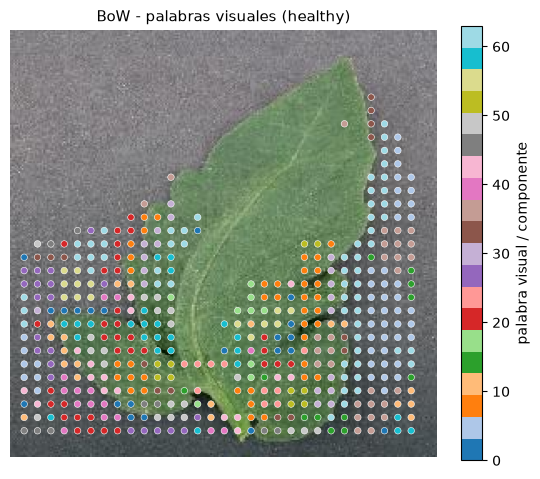

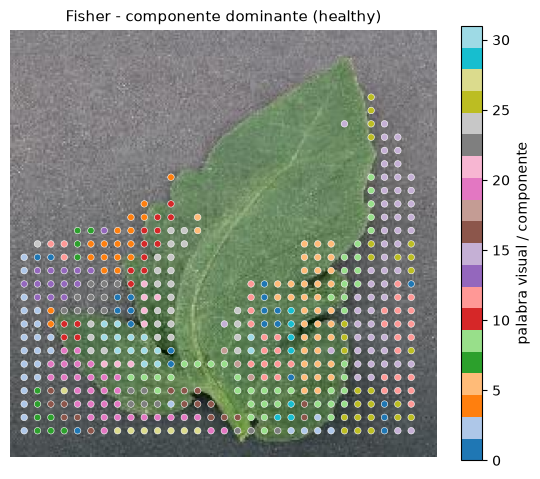

In [72]:
graficar_mapa_caracteristicas(bgr, kp_bow, et_bow,
    f"BoW - palabras visuales ({etiqueta_corta(clase)})", kmeans_bow.n_clusters)
graficar_mapa_caracteristicas(bgr, kp_fv, et_fv,
    f"Fisher - componente dominante ({etiqueta_corta(clase)})", gmm_fisher.n_components)

### Descriptor

In [73]:
# ============================================================
# BLOQUE A - Color (canal a* de Lab dentro de la hoja)
# ============================================================
 
def descriptor_color(bgr, mascara_aj, canal=None):
    """Una hoja sana tiene un canal a* concentrado y estable; una hoja con
    lesiones tiene valores mas altos (mas rojo/marron) y mas dispersos.
    """
    ch = canal_analisis(bgr, canal)
    vals = ch[mascara_aj > 0].astype(np.float64)
    if len(vals) == 0:
        return np.zeros(6, dtype=np.float32)
 
    media = vals.mean()
    std = vals.std()
    if std > 0:
        skew = ((vals - media) ** 3).mean() / (std ** 3)
    else:
        skew = 0.0
    p10, p50, p90 = np.percentile(vals, [10, 50, 90])
 
    return np.array([media, std, skew, p10, p50, p90], dtype=np.float32)

In [74]:
# ============================================================
# BLOQUE B - Textura (GLCM sobre el canal a*)
# ============================================================
 
def descriptor_textura_glcm(bgr, mascara_aj, canal=None, niveles=32, distancias=(1, 3), angulos=(0, np.pi / 4, np.pi / 2, 3 * np.pi / 4)):
    """Matriz de co-ocurrencia de niveles de gris calculada solo sobre el
    bounding box de la hoja (los pixeles fuera de mascara se ponen a 0,
    lo que sesga un poco la GLCM pero es una aproximacion estandar y
    barata; alternativa mas cara: recorrer solo la region con una mascara
    poligonal). Se reduce a `niveles` para que la matriz no sea gigante.
    Se agregan las estadisticas con el promedio sobre todos los
    angulos/distancias para dar invarianza aproximada a la orientacion.
    """
    ch = canal_analisis(bgr, canal)
    ys, xs = np.where(mascara_aj > 0)
    if len(ys) == 0:
        return np.zeros(5, dtype=np.float32)
 
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    recorte = ch[y0:y1, x0:x1].copy()
    mask_recorte = mascara_aj[y0:y1, x0:x1]
    recorte[mask_recorte == 0] = 0
 
    cuantizada = (recorte.astype(np.float64) / 256 * niveles).astype(np.uint8)
    cuantizada = np.clip(cuantizada, 0, niveles - 1)
 
    glcm = graycomatrix(cuantizada, distances=list(distancias), angles=list(angulos),
                         levels=niveles, symmetric=True, normed=True)
 
    props = ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']
    vector = [graycoprops(glcm, p).mean() for p in props]
    return np.array(vector, dtype=np.float32)

In [75]:
# ============================================================
# BLOQUE C - Forma / distribucion de manchas
# ============================================================
 
def detectar_manchas(bgr, mascara_aj, canal=None, umbral_pctl=75, area_min=20):
    """Segmenta 'manchas' como la region con valores de a* por encima del
    percentil `umbral_pctl` DENTRO de la hoja (mas rojo/marron que el
    resto del tejido), y las etiqueta como componentes conexas.
 
    `area_min` descarta componentes mas chicas que ese numero de pixeles:
    sin este filtro, ruido de 1-2 pixeles sueltos que sobrevive a la
    apertura morfologica se cuenta como una "mancha" mas y sobreestima
    el numero de lesiones (ver figura de ejemplo)."""
    ch = canal_analisis(bgr, canal)
    vals = ch[mascara_aj > 0]
    if len(vals) == 0:
        return np.zeros_like(mascara_aj, dtype=np.int32), 0
 
    umbral = np.percentile(vals, umbral_pctl)
    binaria = ((ch > umbral) & (mascara_aj > 0)).astype(np.uint8)
    # limpiar ruido de un solo pixel
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN,
                                cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    etiquetas, n = ndimage.label(binaria)
 
    if n > 0 and area_min > 0:
        tamanos = ndimage.sum(binaria, etiquetas, index=range(1, n + 1))
        descartar = [i + 1 for i, t in enumerate(tamanos) if t < area_min]
        if descartar:
            mask_descarte = np.isin(etiquetas, descartar)
            etiquetas[mask_descarte] = 0
            etiquetas, n = ndimage.label(etiquetas > 0)
 
    return etiquetas, n

In [76]:
def descriptor_forma_manchas(bgr, mascara_aj, canal=None, umbral_pctl=75, area_min=20):
    """Numero de manchas, area total relativa a la hoja, tamano promedio,
    desviacion del tamano (uniforme vs. irregular) y dispersion espacial
    (distancia promedio entre centroides, normalizada por el tamano de la
    hoja) -> distingue una lesion grande y concentrada (early blight) de
    muchas manchas pequenas y dispersas (septoria).
    """
    etiquetas, n = detectar_manchas(bgr, mascara_aj, canal, umbral_pctl, area_min)
    area_hoja = max((mascara_aj > 0).sum(), 1)
 
    if n == 0:
        return np.zeros(5, dtype=np.float32)
 
    tamanos = ndimage.sum(etiquetas > 0, etiquetas, index=range(1, n + 1))
    centroides = ndimage.center_of_mass(etiquetas > 0, etiquetas, index=range(1, n + 1))
    centroides = np.array(centroides)
 
    area_total_rel = tamanos.sum() / area_hoja
    tam_medio_rel = tamanos.mean() / area_hoja
    tam_std_rel = tamanos.std() / area_hoja
 
    if n > 1:
        dists = []
        for i in range(len(centroides)):
            for j in range(i + 1, len(centroides)):
                dists.append(np.linalg.norm(centroides[i] - centroides[j]))
        dispersión = np.mean(dists) / np.sqrt(area_hoja)
    else:
        dispersión = 0.0
 
    return np.array([n, area_total_rel, tam_medio_rel, tam_std_rel, dispersión],
                     dtype=np.float32)

In [77]:
# ============================================================
# Descriptor propio combinado (A + B + C)
# ============================================================ 
def descriptor_propio(bgr, mascara, canal=None):
    """Concatena color + textura GLCM + forma de manchas. Cada bloque se
    calcula tambien por separado (ver mas abajo) para poder comparar en
    el informe cual aporta mas a la clasificacion."""
    maj = ajustar_mascara(mascara)
    color = descriptor_color(bgr, maj, canal)
    textura = descriptor_textura_glcm(bgr, maj, canal)
    forma = descriptor_forma_manchas(bgr, maj, canal)
    return np.concatenate([color, textura, forma]), (color, textura, forma)

In [78]:
for ruta, clase, bgr, mascara in muestra_procesada[:4]:
    vector, (color, textura, forma) = descriptor_propio(bgr, mascara, canal=CANAL)
    print(f"{etiqueta_corta(clase):<26} color={color.round(1)} textura={textura.round(3)} forma={forma.round(2)}")

healthy                    color=[118.9   8.9  -0.  108.  117.  128. ] textura=[5.099 0.938 0.463 0.945 0.429] forma=[23.    0.05  0.    0.    0.69]
healthy                    color=[119.9   9.   -0.5 107.  125.  128. ] textura=[3.958 0.957 0.51  0.962 0.324] forma=[5.   0.03 0.01 0.01 0.77]
healthy                    color=[121.4   9.4  -0.7 107.  128.  129. ] textura=[6.009 0.953 0.623 0.945 0.443] forma=[13.    0.02  0.    0.    0.8 ]
healthy                    color=[123.3  10.1   0.  111.  119.  135. ] textura=[5.073 0.925 0.481 0.953 0.441] forma=[2.0e+01 1.7e-01 1.0e-02 2.0e-02 5.8e-01]


In [79]:

# ============================================================
# Visualizacion: mapa de manchas detectadas (para el bloque C)
# ============================================================
 
def graficar_manchas(bgr, mascara_aj, canal=None, umbral_pctl=75, area_min=20, titulo="", ruta_salida=None):
    etiquetas, n = detectar_manchas(bgr, mascara_aj, canal, umbral_pctl, area_min)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
 
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(rgb)
    axes[0].set_title("Original")
    axes[0].axis('off')
 
    overlay = rgb.copy()
    overlay[etiquetas > 0] = [255, 0, 0]
    axes[1].imshow(overlay)
    axes[1].set_title(f"{n} manchas detectadas")
    axes[1].axis('off')
 
    plt.suptitle(titulo, fontsize=12)
    plt.tight_layout()
    if ruta_salida:
        guardar(ruta_salida)
    plt.show()
    plt.close(fig)

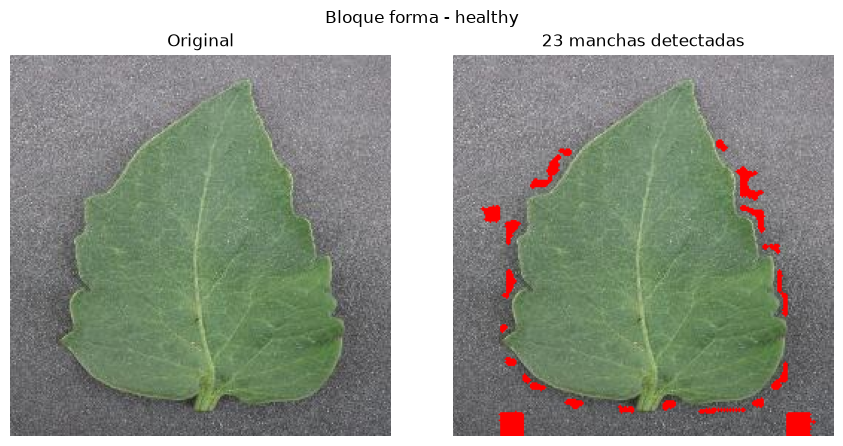

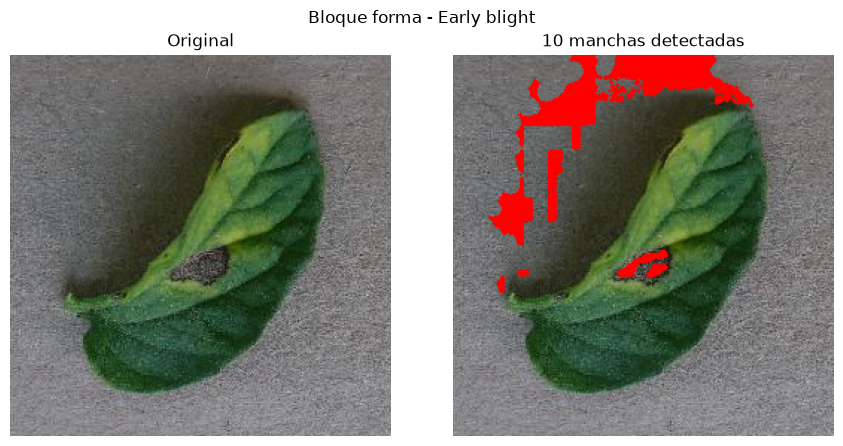

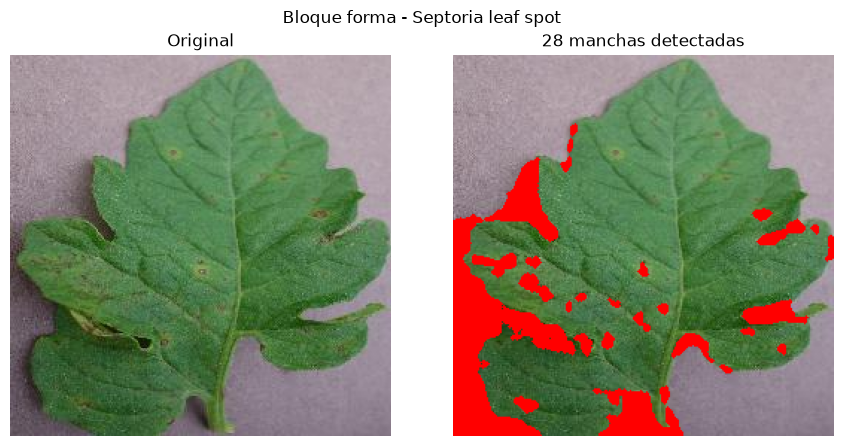

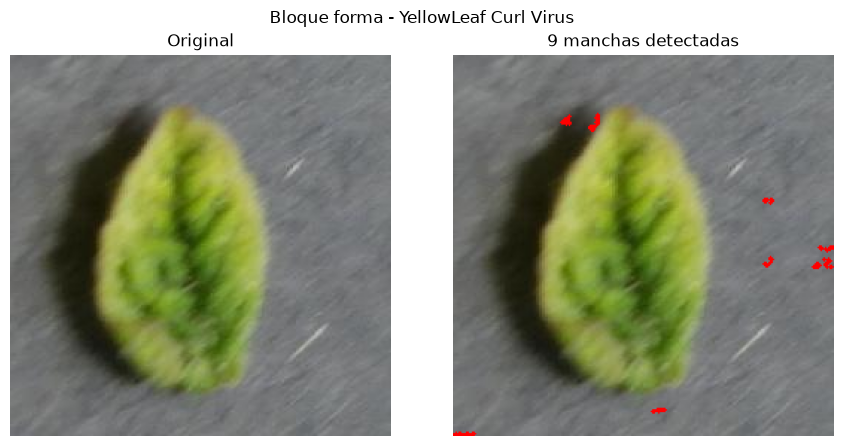

In [80]:
vistas = set()
for ruta, clase, bgr, mascara in muestra_procesada:
    et = etiqueta_corta(clase)
    if et in vistas:
        continue
    vistas.add(et)
    maj = ajustar_mascara(mascara)
    graficar_manchas(bgr, maj, canal=CANAL, titulo=f"Bloque forma - {et}")

In [ ]:
# ============================================================
# Sección 7: Matriz de datos (BoW, Fisher y descriptor propio)
# para la clasificación
# ============================================================

N_POR_CLASE_DATOS = 40

muestra_grande = []
for clase in CLASES_FOCO:
    for ruta in imagenes_de_clase(clase, n=N_POR_CLASE_DATOS):
        bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
        muestra_grande.append((ruta, clase, bgr, mascara))

print("Imágenes para matriz final:", len(muestra_grande),
      "(", N_POR_CLASE_DATOS, "por clase x", len(CLASES_FOCO), "clases )")

Imágenes para matriz final: 160 ( 40 por clase x 4 clases )


In [90]:
# Ajustamos vocabulario/GMM sobre las mismas imágenes que vamos a codificar
# (antes se habían ajustado sobre una muestra de solo 24 imágenes, muy chica).

kmeans_bow = construir_vocabulario_bow(muestra_grande, k=64, canal=CANAL)
gmm_fisher = construir_gmm_fisher(muestra_grande, k=32, canal=CANAL)

[BoW] descriptores para el vocabulario: (32000, 128)
[Fisher] descriptores para el GMM: (32000, 128)


c:\Users\sauto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [91]:
filas_avz, vec_bow, vec_fisher, vec_propio = [], [], [], []

for ruta, clase, bgr, mascara in muestra_grande:
    maj = ajustar_mascara(mascara)

    hist_bow, _, _   = codificar_bow(bgr, mascara, kmeans_bow, canal=CANAL)
    fv, _, _         = codificar_fisher(bgr, mascara, gmm_fisher, canal=CANAL)
    vec_prop, _      = descriptor_propio(bgr, mascara, canal=CANAL)

    vec_bow.append(hist_bow)
    vec_fisher.append(fv)
    vec_propio.append(vec_prop)
    filas_avz.append({"ruta": ruta, "clase": clase, "sana": es_sana(clase)})

X_bow    = np.vstack(vec_bow)
X_fisher = np.vstack(vec_fisher)
X_propio = np.vstack(vec_propio)
y_avz    = np.array([f["clase"] for f in filas_avz])

print("X_bow:   ", X_bow.shape)
print("X_fisher:", X_fisher.shape)
print("X_propio:", X_propio.shape)
print("y:       ", y_avz.shape, "-> clases:", sorted(set(y_avz)))

X_bow:    (160, 64)
X_fisher: (160, 8192)
X_propio: (160, 16)
y:        (160,) -> clases: [np.str_('Tomato_Early_blight'), np.str_('Tomato_Septoria_leaf_spot'), np.str_('Tomato__Tomato_YellowLeaf__Curl_Virus'), np.str_('Tomato_healthy')]


In [92]:
import pandas as pd

def exportar_descriptor(X, nombre, filas):
    columnas = [f"{nombre}_{i}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=columnas)
    df.insert(0, "sana", [f["sana"] for f in filas])
    df.insert(0, "clase", [f["clase"] for f in filas])
    df.insert(0, "ruta", [f["ruta"] for f in filas])

    ruta_csv = os.path.join(FEATS, f"{nombre}_features.csv")
    df.to_csv(ruta_csv, index=False)
    print("guardado:", ruta_csv, "|", df.shape)

    ruta_npz = os.path.join(FEATS, f"{nombre}_features.npz")
    np.savez(ruta_npz, X=X, y=y_avz,
              rutas=np.array([f["ruta"] for f in filas]))
    print("guardado:", ruta_npz)

exportar_descriptor(X_bow,    "bow",    filas_avz)
exportar_descriptor(X_fisher, "fisher", filas_avz)
exportar_descriptor(X_propio, "propio", filas_avz)

guardado: features\bow_features.csv | (160, 67)
guardado: features\bow_features.npz
guardado: features\fisher_features.csv | (160, 8195)
guardado: features\fisher_features.npz
guardado: features\propio_features.csv | (160, 19)
guardado: features\propio_features.npz


In [93]:
import pickle

with open(os.path.join(FEATS, "kmeans_bow.pkl"), "wb") as f:
    pickle.dump(kmeans_bow, f)

with open(os.path.join(FEATS, "gmm_fisher.pkl"), "wb") as f:
    pickle.dump(gmm_fisher, f)

print("modelos guardados en", FEATS)

modelos guardados en features
